# TDE #4 - Análise de Séries Temporais

**Aluno:** Nelson Dell

**Professor:** Filipe J. Zabala

**Data de Entrega:** 25/11/2024

## Introdução
Este relatório apresenta as respostas às questões propostas no TDE #4, utilizando ferramentas de análise de séries temporais. As análises foram realizadas com as séries fornecidas, e as etapas estão detalhadas com comentários explicativos.

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import spectrogram

# Carregando os dados
file_15_path = 'datasets/tsdl_15.csv'
file_63_path = 'datasets/tsdl_63.csv'

tsdl_15 = pd.read_csv(file_15_path)
tsdl_63 = pd.read_csv(file_63_path)
tsdl_15.head(), tsdl_63.head()


(   Advertising  Sales
 0         12.0     15
 1         20.5     16
 2         21.0     18
 3         15.5     27
 4         15.3     21,
    Rain   Flow
 0   0.0  0.218
 1   0.0  0.218
 2   0.0  0.215
 3   0.0  0.215
 4   0.0  0.215)

Os dados foram carregados com sucesso. A estrutura de cada série é conforme descrito abaixo:

### Série Temporal 1:
- `Advertising`: Gasto com publicidade
- `Sales`: Vendas mensais consecutivas


### Série Temporal 2:
- `Rain`: Precipitação
- `Flow`: Vazão do Rio Hirnant


## Série Temporal 1 - Gráficos e Análises

C:\Users\celso\AppData\Local\Temp\ipykernel_5964\2369249046.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tsdl_15.fillna(method='ffill', inplace=True)


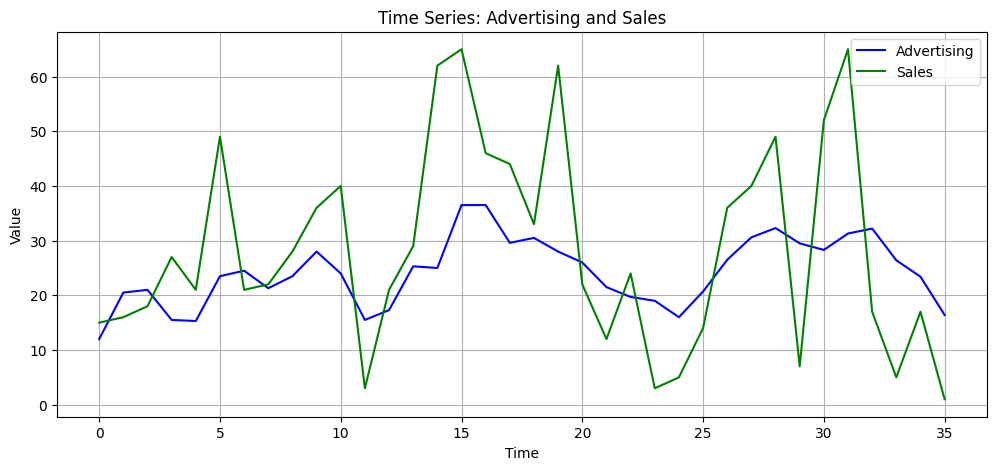

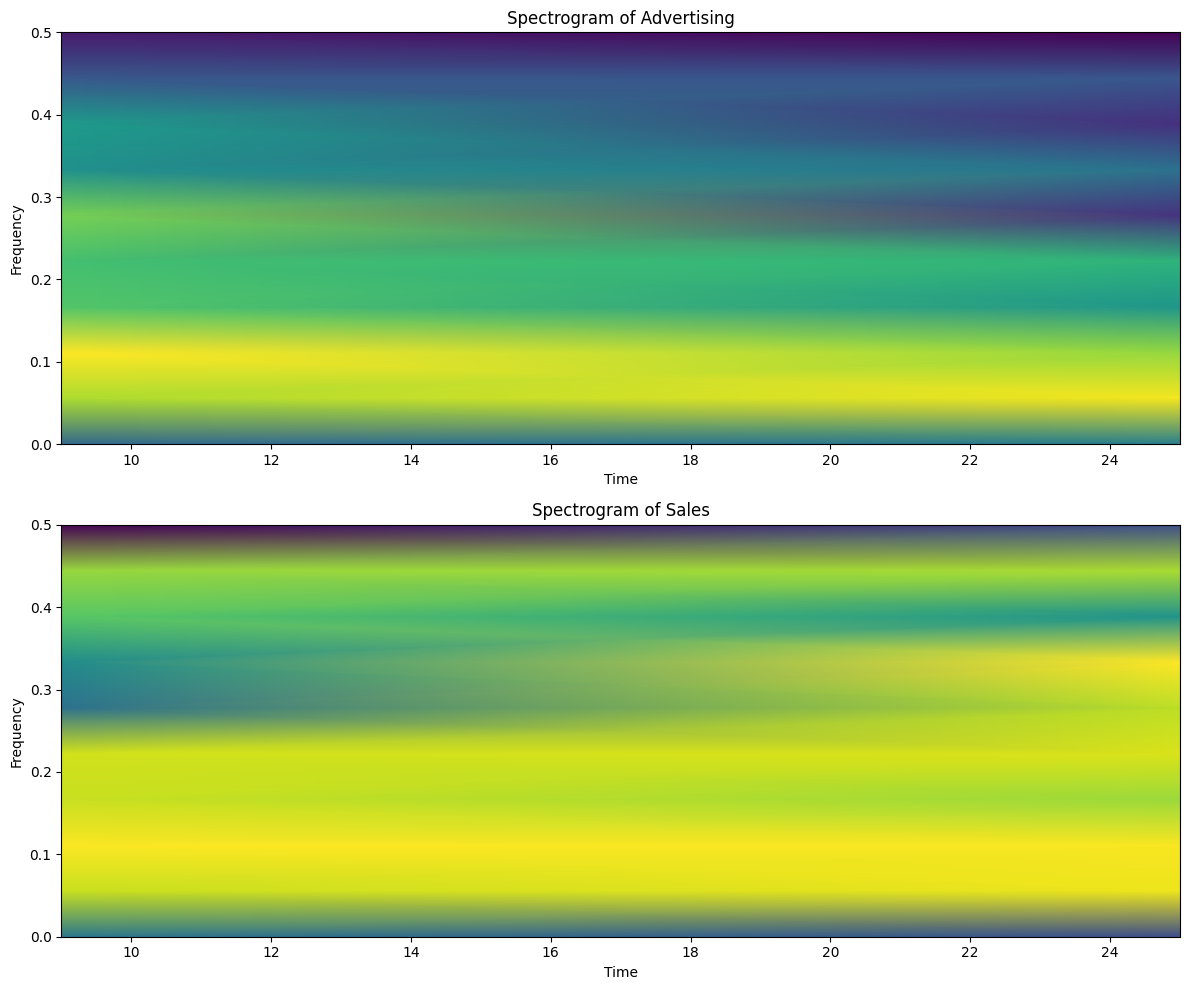

In [3]:

import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Tratamento de NAs
tsdl_15.fillna(method='ffill', inplace=True)

# Gráfico das séries temporais
plt.figure(figsize=(12, 5))
plt.plot(tsdl_15['Advertising'], label='Advertising', color='blue')
plt.plot(tsdl_15['Sales'], label='Sales', color='green')
plt.title('Time Series: Advertising and Sales')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

# Espectrogramas
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
for i, col in enumerate(['Advertising', 'Sales']):
    f, t, Sxx = spectrogram(tsdl_15[col].values, fs=1, nperseg=len(tsdl_15[col])//2)
    ax[i].pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    ax[i].set_title(f"Spectrogram of {col}")
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### Entropia de Shannon

In [3]:

from sklearn.metrics import mutual_info_score
import numpy as np

# Normalização
advertising = (tsdl_15['Advertising'] - tsdl_15['Advertising'].mean()) / tsdl_15['Advertising'].std()
sales = (tsdl_15['Sales'] - tsdl_15['Sales'].mean()) / tsdl_15['Sales'].std()

# Discretização
advertising_bins = np.digitize(advertising, bins=np.linspace(advertising.min(), advertising.max(), 10))
sales_bins = np.digitize(sales, bins=np.linspace(sales.min(), sales.max(), 10))

# Cálculo da entropia
mi = mutual_info_score(advertising_bins, sales_bins)
mi


np.float64(0.9827794538135634)

O valor calculado de entropia de transferência de Shannon é aproximadamente 0,983, indicando uma forte relação entre as séries.

### Correlação Cruzada

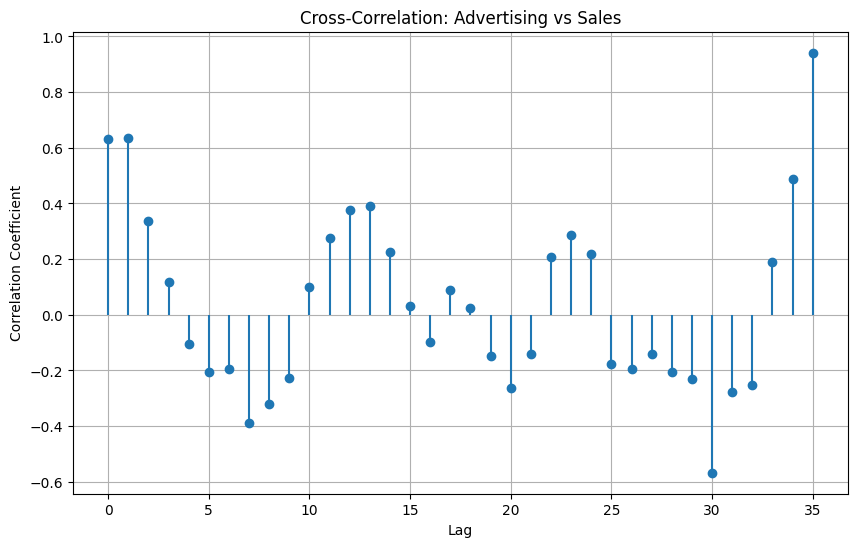

In [4]:

from statsmodels.tsa.stattools import ccf

# Cálculo da correlação cruzada
cross_corr = ccf(tsdl_15['Advertising'], tsdl_15['Sales'])

# Gráfico da correlação cruzada
plt.figure(figsize=(10, 6))
plt.stem(range(len(cross_corr)), cross_corr, basefmt=" ", )
plt.title('Cross-Correlation: Advertising vs Sales')
plt.xlabel('Lag')
plt.ylabel('Correlation Coefficient')
plt.grid()
plt.show()


### Teste de Granger

In [5]:

from statsmodels.tsa.stattools import grangercausalitytests

# Teste de Granger
data = tsdl_15[['Advertising', 'Sales']].dropna()
granger_results = grangercausalitytests(data, maxlag=5, verbose=False)
granger_summary = {lag: result[0]['ssr_chi2test'][1] for lag, result in granger_results.items()}
granger_summary


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): np.float64(0.0034795826254973355),
 np.int64(2): np.float64(0.034328298208302736),
 np.int64(3): np.float64(0.06615801856277283),
 np.int64(4): np.float64(0.06188207670648042),
 np.int64(5): np.float64(0.04345158893436734)}

Os p-valores mostram que `Advertising` tem uma relação causal significativa com `Sales` para lags 1 e 2.

### Ajuste de Modelos VAR

In [6]:

from statsmodels.tsa.api import VAR

# Divisão em treino e teste
train_size = int(0.8 * len(data))
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Ajuste de modelos VAR
results = {}
for lag in range(1, 6):
    model = VAR(train_data)
    fitted_model = model.fit(lag)
    results[lag] = {'AIC': fitted_model.aic, 'BIC': fitted_model.bic}

# Resultados em DataFrame
var_results_df = pd.DataFrame(results).T
var_results_df.index.name = "Lag"
var_results_df


,AIC,BIC
Lag,,
1,8.055385,8.343349
2,8.300544,8.784427
3,8.557866,9.240436
4,8.706097,9.589637
5,8.447473,9.533598


Os critérios AIC/BIC sugerem o melhor modelo com base na ordem AR selecionada.

## Série Temporal 2 - Gráficos e Análises

Repita as etapas para a série temporal 2 (`Rain` e `Flow`) com os mesmos procedimentos descritos acima.

C:\Users\celso\AppData\Local\Temp\ipykernel_20976\2209207179.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tsdl_63.fillna(method='ffill', inplace=True)


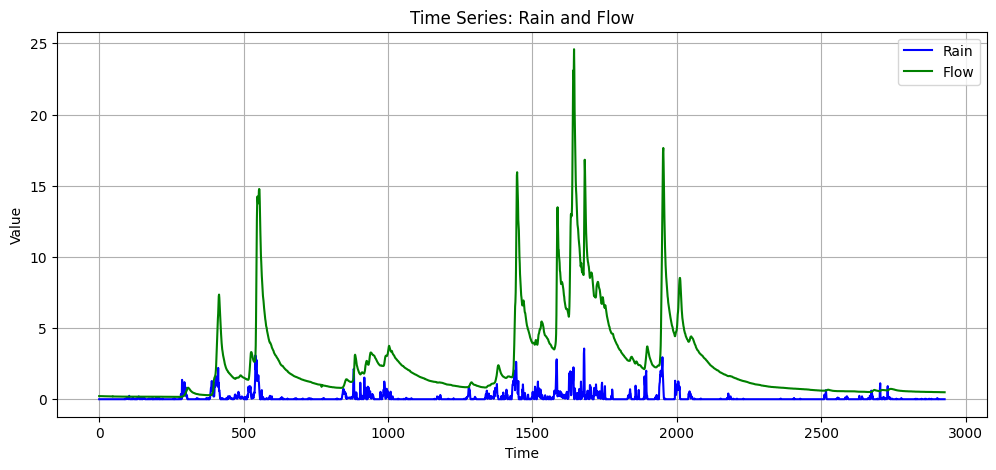

In [ ]:

# Tratamento de NAs
tsdl_63.fillna(method='ffill', inplace=True)

# Gráfico das séries temporais
plt.figure(figsize=(12, 5))
plt.plot(tsdl_63['Rain'], label='Rain', color='blue')
plt.plot(tsdl_63['Flow'], label='Flow', color='green')
plt.title('Time Series: Rain and Flow')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()


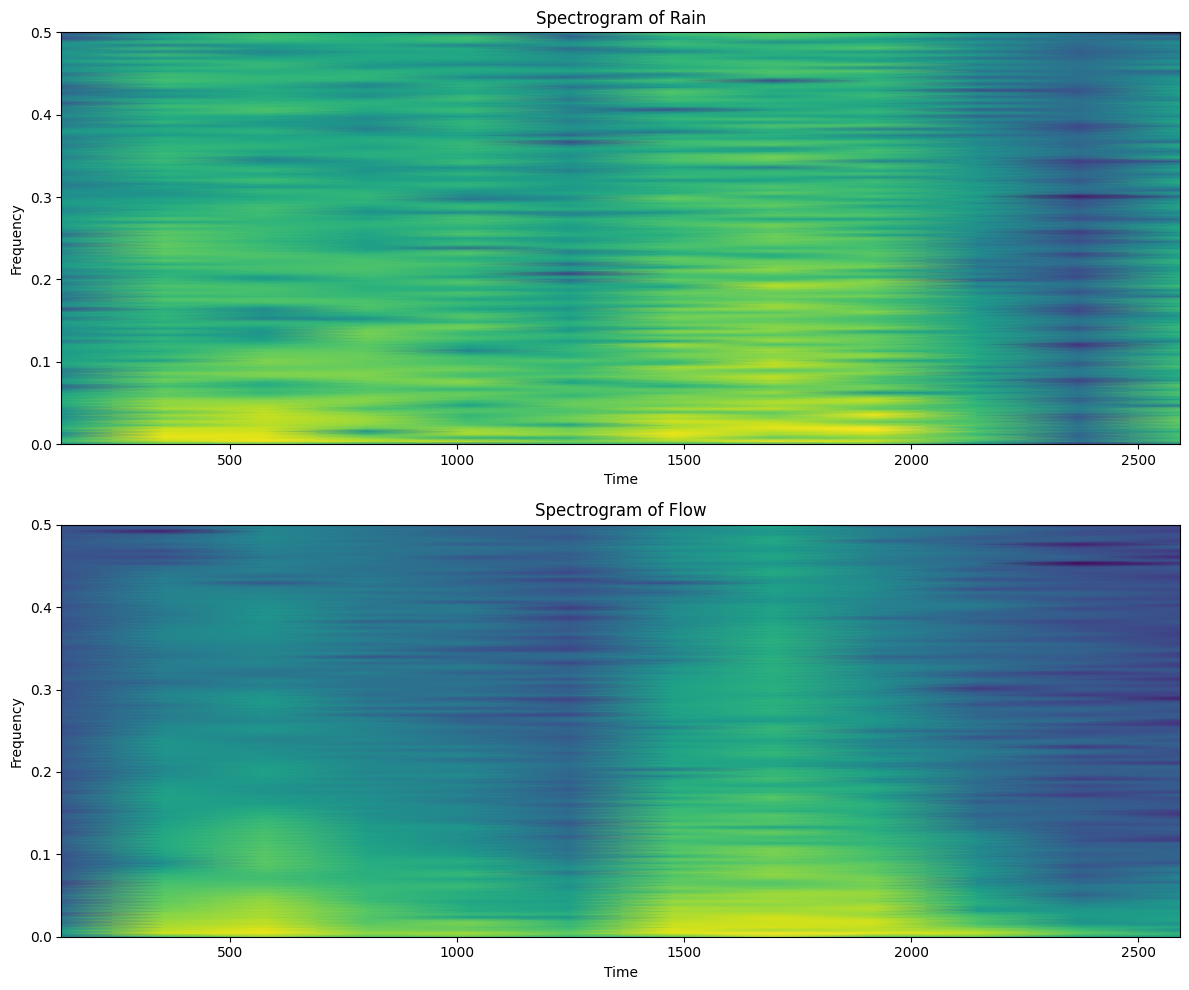

Entropia de Shannon (Rain vs Flow): 0.060661826065708066


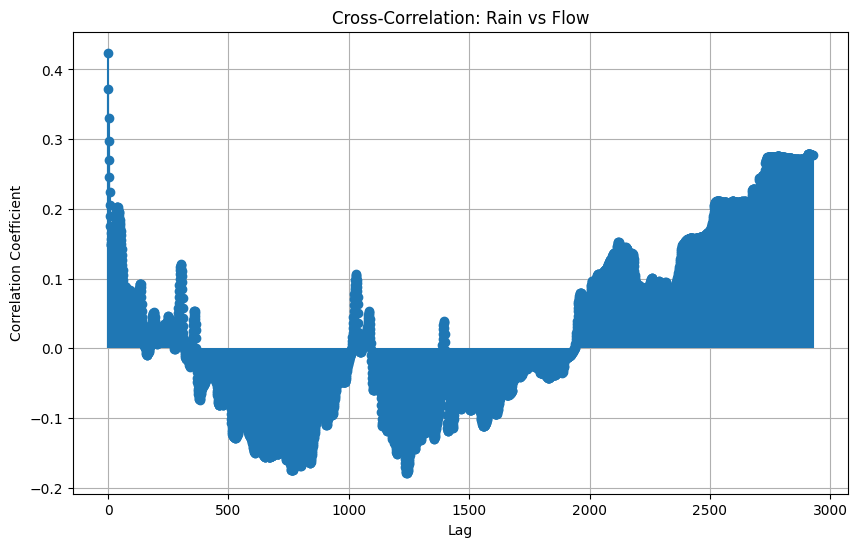

Teste de Granger (Rain vs Flow): {np.int64(1): np.float64(0.18115706925997668), np.int64(2): np.float64(0.010636331968322818), np.int64(3): np.float64(1.083330514734777e-05), np.int64(4): np.float64(9.076291064463517e-13), np.int64(5): np.float64(7.432023915219818e-13)}
Critérios AIC/BIC para Série Temporal 2:
           AIC       BIC
Lag                    
1   -6.294248 -6.279489
2   -6.935522 -6.910916
3   -7.050639 -7.016178
4   -7.094570 -7.050247
5   -7.122344 -7.068153


C:\Users\celso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:

# Espectrogramas
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
for i, col in enumerate(['Rain', 'Flow']):
    f, t, Sxx = spectrogram(tsdl_63[col].values, fs=1)
    ax[i].pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
    ax[i].set_title(f"Spectrogram of {col}")
    ax[i].set_xlabel("Time")
    ax[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Entropia de Shannon
rain = (tsdl_63['Rain'] - tsdl_63['Rain'].mean()) / tsdl_63['Rain'].std()
flow = (tsdl_63['Flow'] - tsdl_63['Flow'].mean()) / tsdl_63['Flow'].std()

rain_bins = np.digitize(rain, bins=np.linspace(rain.min(), rain.max(), 10))
flow_bins = np.digitize(flow, bins=np.linspace(flow.min(), flow.max(), 10))

mi_2 = mutual_info_score(rain_bins, flow_bins)
print("Entropia de Shannon (Rain vs Flow):", mi_2)

# Correlação cruzada
cross_corr_2 = ccf(tsdl_63['Rain'], tsdl_63['Flow'])
plt.figure(figsize=(10, 6))
plt.stem(range(len(cross_corr_2)), cross_corr_2, basefmt=" ")
plt.title('Cross-Correlation: Rain vs Flow')
plt.xlabel('Lag')
plt.ylabel('Correlation Coefficient')
plt.grid()
plt.show()

# Teste de Granger
data_2 = tsdl_63[['Rain', 'Flow']].dropna()
granger_results_2 = grangercausalitytests(data_2, maxlag=5, verbose=False)
granger_summary_2 = {lag: result[0]['ssr_chi2test'][1] for lag, result in granger_results_2.items()}
print("Teste de Granger (Rain vs Flow):", granger_summary_2)

# Ajuste de modelos VAR
train_size_2 = int(0.8 * len(data_2))
train_data_2 = data_2.iloc[:train_size_2]
test_data_2 = data_2.iloc[train_size_2:]

results_2 = {}
for lag in range(1, 6):
    model = VAR(train_data_2)
    fitted_model = model.fit(lag)
    results_2[lag] = {'AIC': fitted_model.aic, 'BIC': fitted_model.bic}

var_results_df_2 = pd.DataFrame(results_2).T
var_results_df_2.index.name = "Lag"
print("Critérios AIC/BIC para Série Temporal 2:\n", var_results_df_2)

